#**Disease Prediction from Medical Data**

## **CodeAlpha Machine Learning Internship Project**

### **Objective**
To predict the possibility of heart disease using Machine Learning algorithms based on patient medical data.

### **Install XGBoost**

In [ ]:
!pip install xgboost -q

### **Import Libraries**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# **Dataset Information**

The project uses the Heart Disease Dataset.

The dataset contains medical attributes such as:
- Age
- Cholesterol
- Blood Pressure
- Chest Pain Type
- ECG Results
- Heart Rate

Target:
- 1 → Disease Present
- 0 → No Disease

### **Load Dataset**

In [ ]:
df = pd.read_csv("heart.csv")

### **Display First 5 Rows**

In [ ]:
print("FIRST 5 ROWS OF DATASET")

df.head()

FIRST 5 ROWS OF DATASET


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


### **Dataset Shape**

In [ ]:
print("DATASET SHAPE")

print(df.shape)

DATASET SHAPE
(1025, 14)


### **Dataset Information**

In [ ]:
print("DATASET INFORMATION")

df.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


### **Check Missing Values**

In [ ]:
print("MISSING VALUES")

print(df.isnull().sum())

MISSING VALUES
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


### **Statistical Summary**

In [ ]:
print("STATISTICAL SUMMARY")

df.describe()

STATISTICAL SUMMARY


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


# **Data Visualization**

Data visualization helps in understanding:
- Disease distribution
- Age distribution
- Correlation between features
- Patterns in patient data

### **Disease Distribution Pie Chart**

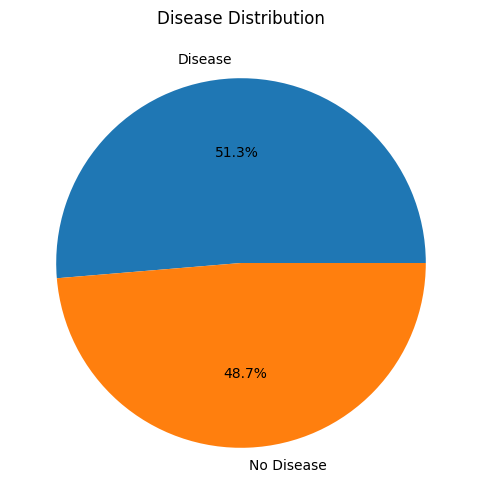

In [ ]:
disease_counts = df['target'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    disease_counts,
    labels=["Disease", "No Disease"],
    autopct='%1.1f%%'
)

plt.title("Disease Distribution")

plt.show()

### **Age Distribution Histogram**

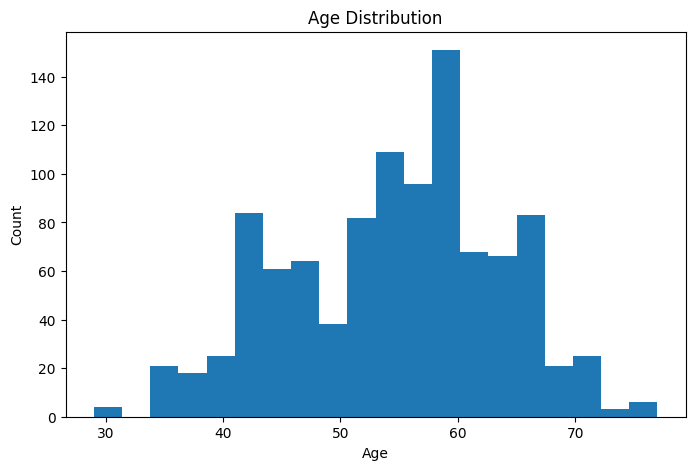

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df['age'], bins=20)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Count")

plt.show()

### **Correlation Heatmap**

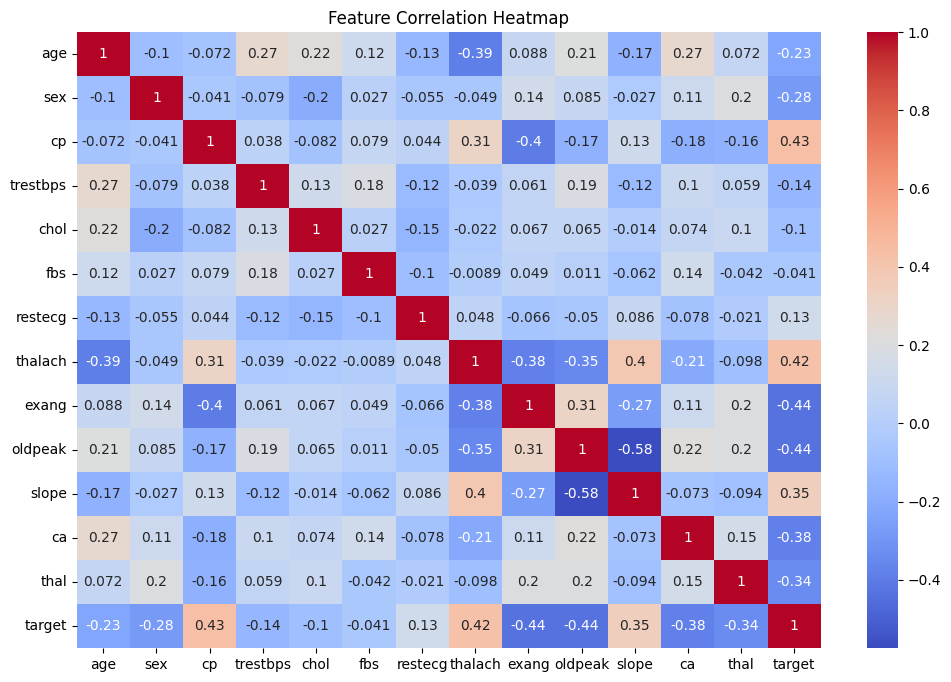

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

# **Data Preprocessing**

The dataset is divided into:
- Features (X)
- Target (y)

Feature scaling is applied using StandardScaler for better model performance.

### **Features and Target**

In [ ]:
X = df.drop("target", axis=1)

y = df["target"]

### **Train Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### **Feature Scaling**

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# **Machine Learning Models**

The following classification algorithms are used:

1. Logistic Regression
2. Support Vector Machine (SVM)
3. Random Forest
4. XGBoost

The models are compared based on prediction accuracy.

### **Create Machine Learning Models**

In [ ]:
models = {

    "Logistic Regression": LogisticRegression(),

    "Support Vector Machine": SVC(),

    "Random Forest": RandomForestClassifier(),

    "XGBoost": XGBClassifier()

}

# **Model Evaluation**

The models are evaluated using:
- Accuracy Score
- Classification Report
- Confusion Matrix

The best-performing model is selected for disease prediction.

### **Train and Evaluate Models**

In [ ]:
model_names = []

accuracies = []

for name, model in models.items():

    print("\n============================")
    print(name)
    print("============================")

    # Train Model
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)

    model_names.append(name)

    accuracies.append(accuracy)

    print(f"\nAccuracy: {accuracy:.2f}")

    # Classification Report
    print("\nClassification Report:\n")

    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    print("\nConfusion Matrix:\n")

    print(confusion_matrix(y_test, y_pred))


Logistic Regression

Accuracy: 0.80

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.72      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205


Confusion Matrix:

[[73 29]
 [13 90]]

Support Vector Machine

Accuracy: 0.89

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.83      0.88       102
           1       0.85      0.94      0.89       103

    accuracy                           0.89       205
   macro avg       0.89      0.89      0.89       205
weighted avg       0.89      0.89      0.89       205


Confusion Matrix:

[[85 17]
 [ 6 97]]

Random Forest

Accuracy: 0.99

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1

### **Accuracy Comparison Bar Chart**

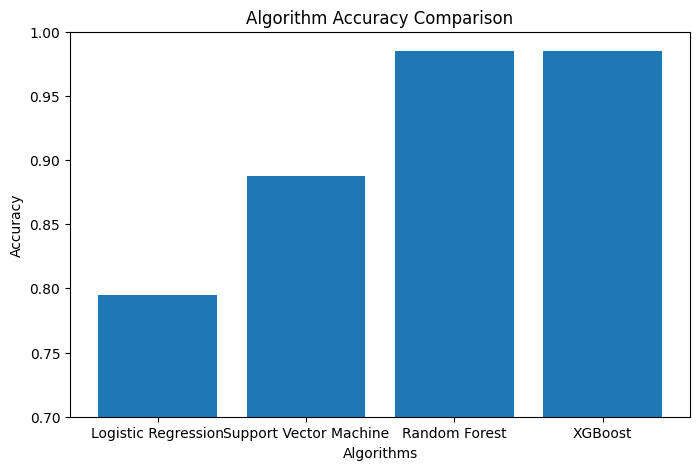

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(model_names, accuracies)

plt.title("Algorithm Accuracy Comparison")

plt.xlabel("Algorithms")

plt.ylabel("Accuracy")

plt.ylim(0.7, 1.0)

plt.show()

### **Confusion Matrix Heatmap**

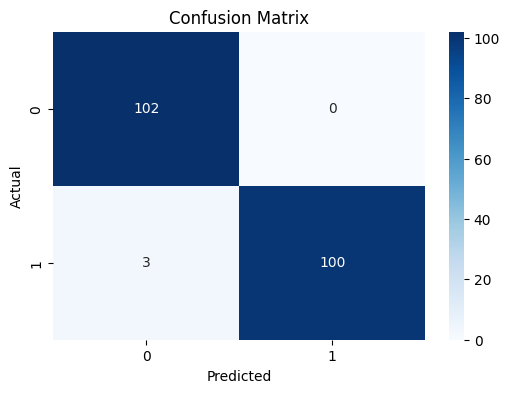

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# **Feature Importance Analysis**

Random Forest is used to identify the most influential medical features affecting disease prediction.

### **Feature Importance Graph**

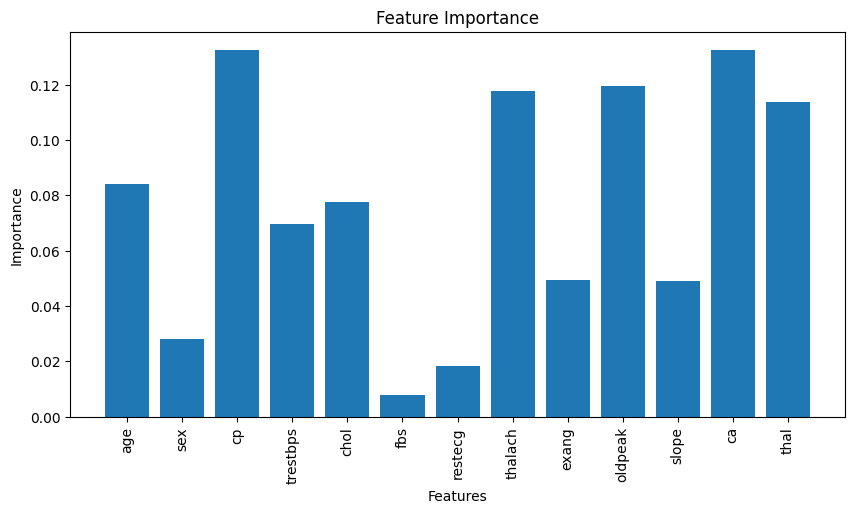

In [ ]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

importance = rf.feature_importances_

features = X.columns

plt.figure(figsize=(10,5))

plt.bar(features, importance)

plt.xticks(rotation=90)

plt.title("Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.show()

# **Final Disease Prediction**

A sample patient's medical data is provided to the trained model to predict whether heart disease is present or not.

### **Sample Patient Data**

In [ ]:
sample_data = np.array([
    52,
    1,
    2,
    172,
    199,
    1,
    1,
    162,
    0,
    0.5,
    2,
    0,
    3
]).reshape(1, -1)

### **Scale Sample Data**

In [ ]:
sample_data = scaler.transform(sample_data)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


### **Train Final Model**

In [ ]:
best_model = RandomForestClassifier()

best_model.fit(X_train, y_train)

RandomForestClassifier()

### **Final Prediction**

In [ ]:
prediction = best_model.predict(sample_data)

### **Display Final Result**

In [ ]:
print("FINAL DISEASE PREDICTION")

if prediction[0] == 1:
    print("\nPatient has Heart Disease")
else:
    print("\nPatient does NOT have Heart Disease")

FINAL DISEASE PREDICTION

Patient has Heart Disease


# **Conclusion**

This project successfully predicts heart disease using Machine Learning techniques.

Different classification algorithms were compared to identify the best-performing model.

The project demonstrates how Machine Learning can assist in medical diagnosis using patient data.